# 🧹 Cuaderno 01 — ETL: Extracción, Transformación y Carga
**Rol:** Ingeniero de Datos  
**Proyecto:** Predicción de Adicción a Redes Sociales en Estudiantes  
**Dataset fuente:** `Students_Social_Media_Addiction.csv` (705 registros · 13 columnas · 0 nulos)

---
**Objetivo de este cuaderno:**  
Limpiar, transformar y exportar el dataset en un formato listo para Machine Learning.  
Genera los archivos procesados que usan los cuadernos 02 al 05.

> 💡 **Rol del Ingeniero de Datos:** Garantizar que los datos lleguen al modelo de ML
> en el formato correcto, sin ruido y con variables que el algoritmo pueda procesar.


## 📦 Paso 1 — Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style='whitegrid', palette='Set2')

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")


✅ Librerías importadas correctamente
   pandas  2.2.2
   numpy   2.0.2


## 📂 Paso 2 — Carga y detección automática del dataset

In [4]:
for ruta in ['/content/Students_Social_Media_Addiction.csv',
             'Students_Social_Media_Addiction.csv']:
    try:
        df_crudo = pd.read_csv(ruta)
        print(f"✅ Archivo cargado: {ruta}")
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError(
        "❌ No se encontró 'Students_Social_Media_Addiction.csv'.\n"
        "   En Google Colab ejecuta:\n"
        "     from google.colab import files; files.upload()"
    )

✅ Archivo cargado: /content/Students_Social_Media_Addiction.csv


## 🔍 Paso 3 — Exploración inicial (perfil del dataset)

In [5]:
print("═"*60)
print("  PERFIL DEL DATASET — ANTES DE LIMPIEZA")
print("═"*60)

perfil = pd.DataFrame({
    'Tipo de Dato':    df_crudo.dtypes.astype(str),
    'Valores Nulos':   df_crudo.isnull().sum(),
    '% Nulos':        (df_crudo.isnull().sum()/len(df_crudo)*100).round(1),
    'Valores Únicos':  df_crudo.nunique(),
    'Ejemplo':         [df_crudo[c].dropna().iloc[0] if len(df_crudo[c].dropna())>0 else '' for c in df_crudo.columns]
})
display(perfil)

print("\n📊 Estadísticas descriptivas — variables numéricas:")
display(df_crudo.describe().round(2))


════════════════════════════════════════════════════════════
  PERFIL DEL DATASET — ANTES DE LIMPIEZA
════════════════════════════════════════════════════════════


,Tipo de Dato,Valores Nulos,% Nulos,Valores Únicos,Ejemplo
Student_ID,int64,0,0.0,705,1
Age,int64,0,0.0,7,19
Gender,object,0,0.0,2,Female
Academic_Level,object,0,0.0,3,Undergraduate
Country,object,0,0.0,110,Bangladesh
Avg_Daily_Usage_Hours,float64,0,0.0,67,5.2
Most_Used_Platform,object,0,0.0,12,Instagram
Affects_Academic_Performance,object,0,0.0,2,Yes
Sleep_Hours_Per_Night,float64,0,0.0,59,6.5
Mental_Health_Score,int64,0,0.0,6,6



📊 Estadísticas descriptivas — variables numéricas:


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.00,705.00,705.00,705.00,705.00,705.00,705.00
mean,353.00,20.66,4.92,6.87,6.23,2.85,6.44
std,203.66,1.40,1.26,1.13,1.11,0.96,1.59
min,1.00,18.00,1.50,3.80,4.00,0.00,2.00
25%,177.00,19.00,4.10,6.00,5.00,2.00,5.00
50%,353.00,21.00,4.80,6.90,6.00,3.00,7.00
75%,529.00,22.00,5.80,7.70,7.00,4.00,8.00
max,705.00,24.00,8.50,9.60,9.00,5.00,9.00


## 🌍 Paso 4 — Análisis de variables categóricas

In [6]:
print("═"*60)
print("  DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("═"*60)

categoricas = ['Gender','Academic_Level','Most_Used_Platform',
               'Affects_Academic_Performance','Relationship_Status']

for col in categoricas:
    print(f"\n  📌 {col}  ({df_crudo[col].nunique()} categorías únicas)")
    tabla = df_crudo[col].value_counts()
    for val, cnt in tabla.items():
        barra = '█' * int(cnt/len(df_crudo)*40)
        print(f"     {str(val):<28} {cnt:>4}  {cnt/len(df_crudo)*100:5.1f}%  {barra}")

print(f"\n  País: {df_crudo['Country'].nunique()} países distintos — top 5:")
for pais, cnt in df_crudo['Country'].value_counts().head(5).items():
    print(f"     {pais:<20} {cnt}")


════════════════════════════════════════════════════════════
  DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
════════════════════════════════════════════════════════════

  📌 Gender  (2 categorías únicas)
     Female                        353   50.1%  ████████████████████
     Male                          352   49.9%  ███████████████████

  📌 Academic_Level  (3 categorías únicas)
     Undergraduate                 353   50.1%  ████████████████████
     Graduate                      325   46.1%  ██████████████████
     High School                    27    3.8%  █

  📌 Most_Used_Platform  (12 categorías únicas)
     Instagram                     249   35.3%  ██████████████
     TikTok                        154   21.8%  ████████
     Facebook                      123   17.4%  ██████
     WhatsApp                       54    7.7%  ███
     Twitter                        30    4.3%  █
     LinkedIn                       21    3.0%  █
     WeChat                         15    2.1%  
     Snapchat

## 🧼 Paso 5 — Limpieza de datos

In [7]:
df = df_crudo.copy()

# 5.1 Eliminar Student_ID (no informativo para modelos)
df = df.drop(columns=['Student_ID'])
print("✅ 'Student_ID' eliminado (identificador, no predictivo)")

# 5.2 Verificar y eliminar duplicados
n_dup = df.duplicated().sum()
if n_dup > 0:
    df = df.drop_duplicates()
    print(f"✅ {n_dup} filas duplicadas eliminadas")
else:
    print(f"✅ Sin duplicados ({n_dup})")

# 5.3 Verificar nulos
n_nulos = df.isnull().sum().sum()
print(f"✅ Valores nulos totales: {n_nulos} {'(dataset limpio)' if n_nulos==0 else ''}")

# 5.4 Verificar rangos esperados
assert df['Avg_Daily_Usage_Hours'].between(0,24).all(), "Horas fuera de rango"
assert df['Mental_Health_Score'].between(1,10).all(), "Salud mental fuera de rango"
assert df['Addicted_Score'].between(1,10).all(), "Puntaje adicción fuera de rango"
print("✅ Rangos de variables validados correctamente")

print(f"\n📐 Dataset limpio: {df.shape[0]} filas × {df.shape[1]} columnas")


✅ 'Student_ID' eliminado (identificador, no predictivo)
✅ 1 filas duplicadas eliminadas
✅ Valores nulos totales: 0 (dataset limpio)
✅ Rangos de variables validados correctamente

📐 Dataset limpio: 704 filas × 12 columnas


## 🔤 Paso 6 — Renombrado de columnas al español

In [8]:
mapa_columnas = {
    'Age':                           'edad',
    'Gender':                        'genero',
    'Academic_Level':                'nivel_academico',
    'Country':                       'pais',
    'Avg_Daily_Usage_Hours':         'horas_uso_diario',
    'Most_Used_Platform':            'plataforma_principal',
    'Affects_Academic_Performance':  'afecta_rendimiento_academico',
    'Sleep_Hours_Per_Night':         'horas_sueno_noche',
    'Mental_Health_Score':           'puntaje_salud_mental',
    'Relationship_Status':           'estado_relacion',
    'Conflicts_Over_Social_Media':   'conflictos_por_redes',
    'Addicted_Score':                'puntaje_adiccion'
}

df = df.rename(columns=mapa_columnas)

print("✅ Mapa de renombrado aplicado:")
print(f"   {'Variable Original':<38} {'Variable en Español'}")
print(f"   {'-'*38} {'-'*25}")
for orig, nuevo in mapa_columnas.items():
    print(f"   {orig:<38} {nuevo}")


✅ Mapa de renombrado aplicado:
   Variable Original                      Variable en Español
   -------------------------------------- -------------------------
   Age                                    edad
   Gender                                 genero
   Academic_Level                         nivel_academico
   Country                                pais
   Avg_Daily_Usage_Hours                  horas_uso_diario
   Most_Used_Platform                     plataforma_principal
   Affects_Academic_Performance           afecta_rendimiento_academico
   Sleep_Hours_Per_Night                  horas_sueno_noche
   Mental_Health_Score                    puntaje_salud_mental
   Relationship_Status                    estado_relacion
   Conflicts_Over_Social_Media            conflictos_por_redes
   Addicted_Score                         puntaje_adiccion


## 🔢 Paso 7 — Codificación de variables categóricas

### ¿Por qué es necesario transformar variables categóricas?

Los algoritmos de Machine Learning (Regresión Lineal, Logística, Árboles de Decisión)
trabajan exclusivamente con **números**. Una variable como `genero = 'Female'` no puede
sumarse, multiplicarse ni compararse matemáticamente. La codificación convierte texto en
números preservando la información:

| Técnica | Cuándo usar | Ejemplo |
|---|---|---|
| **Label Encoding** | Variables ordinales o con muchas categorías | Nivel académico: HS=0, UG=1, Grad=2 |
| **Binary Encoding** | Variables binarias | Género: Female=0, Male=1 |
| **One-Hot** | Variables nominales sin orden (pocas categorías) | Plataforma → columnas separadas |

En este proyecto usamos **Label Encoding** para todas las categóricas, ya que los árboles
de decisión manejan bien esta codificación y evitamos la explosión de dimensiones del One-Hot.


In [9]:
le = LabelEncoder()
codificaciones = {}

# Genero: Female=0, Male=1
df['genero_enc'] = le.fit_transform(df['genero'])
codificaciones['genero'] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

# Nivel académico: orden pedagógico lógico (no alfabético)
mapa_nivel = {'High School': 0, 'Undergraduate': 1, 'Graduate': 2}
df['nivel_academico_enc'] = df['nivel_academico'].map(mapa_nivel)
codificaciones['nivel_academico'] = mapa_nivel

# País
df['pais_enc'] = le.fit_transform(df['pais'])
codificaciones['pais'] = f'{df["pais"].nunique()} países → 0 a {df["pais"].nunique()-1}'

# Plataforma
df['plataforma_enc'] = le.fit_transform(df['plataforma_principal'])
codificaciones['plataforma'] = dict(zip(sorted(df['plataforma_principal'].unique()),
                                        range(df['plataforma_principal'].nunique())))

# Afecta rendimiento: No=0, Yes=1
df['afecta_rendimiento_enc'] = (df['afecta_rendimiento_academico'] == 'Yes').astype(int)
codificaciones['afecta_rendimiento'] = {'No': 0, 'Yes': 1}

# Estado de relación
df['estado_relacion_enc'] = le.fit_transform(df['estado_relacion'])
codificaciones['estado_relacion'] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

print("✅ Codificación completada. Mapa de transformaciones:")
for var, mapa in codificaciones.items():
    print(f"\n  {var}: {mapa}")


✅ Codificación completada. Mapa de transformaciones:

  genero: {'Female': 0, 'Male': 1}

  nivel_academico: {'High School': 0, 'Undergraduate': 1, 'Graduate': 2}

  pais: 110 países → 0 a 109

  plataforma: {'Facebook': 0, 'Instagram': 1, 'KakaoTalk': 2, 'LINE': 3, 'LinkedIn': 4, 'Snapchat': 5, 'TikTok': 6, 'Twitter': 7, 'VKontakte': 8, 'WeChat': 9, 'WhatsApp': 10, 'YouTube': 11}

  afecta_rendimiento: {'No': 0, 'Yes': 1}

  estado_relacion: {'Complicated': 0, 'In Relationship': 1, 'Single': 2}


## 🎯 Paso 8 — Creación de variables objetivo

In [10]:
# ─────────────────────────────────────────────────────────────
# VARIABLE 1: High_Addiction_Risk (binaria) — para Reg. Logística
# Umbral >= 7 basado en la distribución: el 57% del dataset está en ≥7
# ─────────────────────────────────────────────────────────────
UMBRAL = 7
df['High_Addiction_Risk']   = (df['puntaje_adiccion'] >= UMBRAL).astype(int)
df['adiccion_alta_binario'] = df['High_Addiction_Risk']   # alias en español

# ─────────────────────────────────────────────────────────────
# VARIABLE 2: nivel_adiccion_enc (ordinal) — para Árbol de Decisión
# ─────────────────────────────────────────────────────────────
def clasificar_nivel(score):
    if score <= 4:   return 0   # Baja
    elif score <= 6: return 1   # Media
    else:            return 2   # Alta

df['nivel_adiccion_enc'] = df['puntaje_adiccion'].apply(clasificar_nivel)

print("✅ Variables objetivo creadas:")
print()

# Distribución High_Addiction_Risk
print(f"  High_Addiction_Risk (umbral ≥ {UMBRAL})")
for clase, nombre in [(1,'ALTO riesgo'), (0,'Bajo riesgo')]:
    n = (df['High_Addiction_Risk']==clase).sum()
    pct = n/len(df)*100
    barra = '█'*int(pct/3)
    print(f"    {clase} ({nombre}): {n:>4} ({pct:.1f}%) {barra}")

print()
print("  nivel_adiccion_enc (3 clases)")
for clase, nombre in [(2,'Alta (7–9)'), (1,'Media (5–6)'), (0,'Baja (2–4)')]:
    n = (df['nivel_adiccion_enc']==clase).sum()
    pct = n/len(df)*100
    barra = '█'*int(pct/3)
    print(f"    {clase} ({nombre}): {n:>4} ({pct:.1f}%) {barra}")


✅ Variables objetivo creadas:

  High_Addiction_Risk (umbral ≥ 7)
    1 (ALTO riesgo):  407 (57.8%) ███████████████████
    0 (Bajo riesgo):  297 (42.2%) ██████████████

  nivel_adiccion_enc (3 clases)
    2 (Alta (7–9)):  407 (57.8%) ███████████████████
    1 (Media (5–6)):  197 (28.0%) █████████
    0 (Baja (2–4)):  100 (14.2%) ████


## 📊 Paso 9 — Visualización del perfil ETL

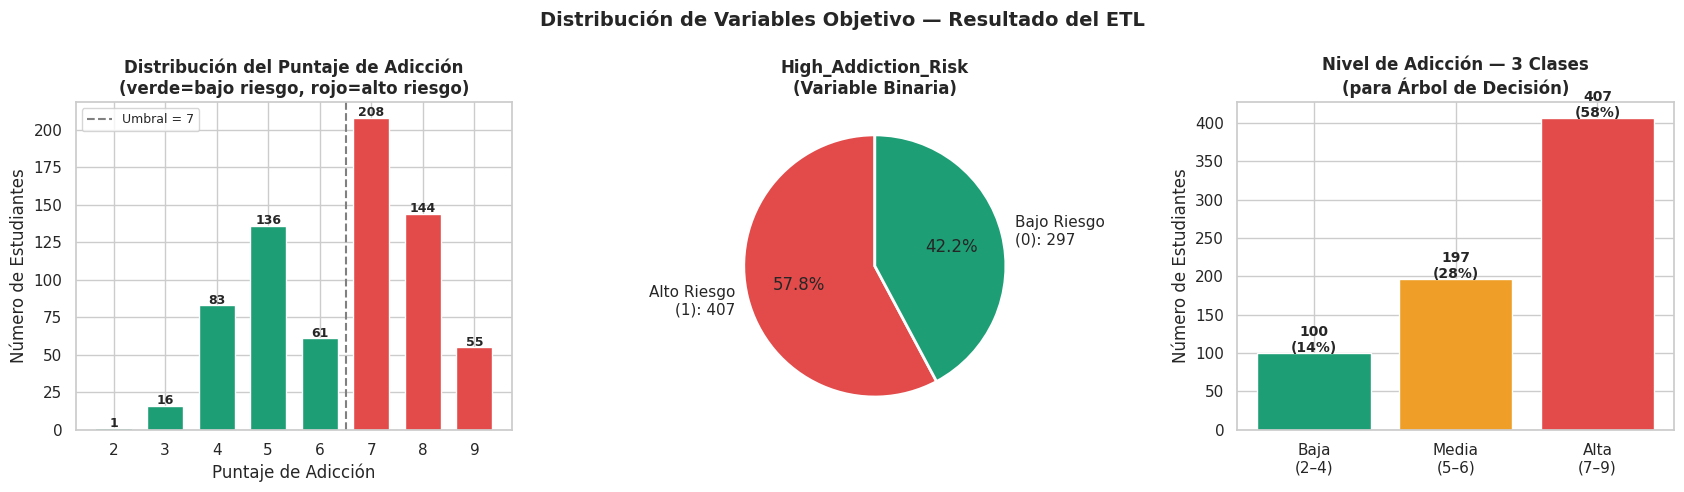

✅ Gráfica guardada: 'etl_variables_objetivo.png'


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Distribución de Variables Objetivo — Resultado del ETL', fontsize=14, fontweight='bold')

# A) Distribución completa del Puntaje de Adicción
ax = axes[0]
conteo = df['puntaje_adiccion'].value_counts().sort_index()
colores = ['#E24B4A' if v >= UMBRAL else '#1D9E75' for v in conteo.index]
bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.7)
ax.axvline(x=UMBRAL-0.5, color='gray', linestyle='--', linewidth=1.5, label=f'Umbral = {UMBRAL}')
for bar, cnt in zip(bars, conteo.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            str(cnt), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Distribución del Puntaje de Adicción\n(verde=bajo riesgo, rojo=alto riesgo)')
ax.set_xlabel('Puntaje de Adicción')
ax.set_ylabel('Número de Estudiantes')
ax.legend(fontsize=9)

# B) High_Addiction_Risk - Pie
ax = axes[1]
conteo_b = df['High_Addiction_Risk'].value_counts()
etiquetas_pie = [f'Alto Riesgo\n(1): {conteo_b.get(1,0)}',
                 f'Bajo Riesgo\n(0): {conteo_b.get(0,0)}']
ax.pie([conteo_b.get(1,0), conteo_b.get(0,0)],
       labels=etiquetas_pie,
       colors=['#E24B4A','#1D9E75'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('High_Addiction_Risk\n(Variable Binaria)')

# C) Nivel de Adicción - 3 clases
ax = axes[2]
nombres_nivel = {0:'Baja\n(2–4)', 1:'Media\n(5–6)', 2:'Alta\n(7–9)'}
conteo_c = df['nivel_adiccion_enc'].value_counts().sort_index()
bars2 = ax.bar([nombres_nivel[i] for i in conteo_c.index], conteo_c.values,
               color=['#1D9E75','#EF9F27','#E24B4A'], edgecolor='white')
for bar, cnt in zip(bars2, conteo_c.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{cnt}\n({cnt/len(df)*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Nivel de Adicción — 3 Clases\n(para Árbol de Decisión)')
ax.set_ylabel('Número de Estudiantes')

plt.tight_layout()
plt.savefig('etl_variables_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada: 'etl_variables_objetivo.png'")

## 💾 Paso 10 — Exportación de datasets procesados

In [14]:
FEATURES_BASE = ['horas_uso_diario', 'conflictos_por_redes', 'horas_sueno_noche',
                 'puntaje_salud_mental', 'genero_enc', 'nivel_academico_enc',
                 'pais_enc', 'plataforma_enc', 'afecta_rendimiento_enc',
                 'estado_relacion_enc', 'edad']

# 1. Dataset completo procesado (nombre compatible con el prompt maestro)
df.to_csv('Students_Addiction_Processed.csv', index=False)
df.to_csv('adiccion_procesado.csv', index=False)  # alias

# 2. Para Regresión Lineal (objetivo: puntaje_adiccion continuo)
cols_lineal = FEATURES_BASE + ['puntaje_adiccion']
df[cols_lineal].to_csv('adiccion_regresion_lineal.csv', index=False)

# 3. Para Regresión Logística (objetivo: High_Addiction_Risk binario)
cols_log = FEATURES_BASE + ['High_Addiction_Risk', 'adiccion_alta_binario']
df[cols_log].to_csv('adiccion_regresion_logistica.csv', index=False)

# 4. Para Árbol de Decisión (objetivo: nivel_adiccion_enc 3 clases)
cols_arbol = FEATURES_BASE + ['nivel_adiccion_enc']
df[cols_arbol].to_csv('adiccion_arboles_decision.csv', index=False)

print("✅ Archivos exportados:")
print(f"   Students_Addiction_Processed.csv  — {df.shape[0]} filas × {df.shape[1]} cols  (dataset maestro)")
print(f"   adiccion_procesado.csv            — alias del anterior")
print(f"   adiccion_regresion_lineal.csv     — {len(cols_lineal)} columnas  (target: puntaje_adiccion)")
print(f"   adiccion_regresion_logistica.csv  — {len(cols_log)} columnas  (target: High_Addiction_Risk)")
print(f"   adiccion_arboles_decision.csv     — {len(cols_arbol)} columnas  (target: nivel_adiccion_enc)")
print()
print("🎉 ETL completado. Pipeline listo para los modelos ML.")

✅ Archivos exportados:
   Students_Addiction_Processed.csv  — 704 filas × 21 cols  (dataset maestro)
   adiccion_procesado.csv            — alias del anterior
   adiccion_regresion_lineal.csv     — 12 columnas  (target: puntaje_adiccion)
   adiccion_regresion_logistica.csv  — 13 columnas  (target: High_Addiction_Risk)
   adiccion_arboles_decision.csv     — 12 columnas  (target: nivel_adiccion_enc)

🎉 ETL completado. Pipeline listo para los modelos ML.
